In [3]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost matplotlib seaborn pandas

In [1]:
import pandas as pd
import requests

# URL da API para os dados KOI
API_URL_KOI = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=json"

print("🚀 Buscando dados da API da NASA (Kepler Objects of Interest)...")

try:
    # Faz a requisição para a API
    response_koi = requests.get(API_URL_KOI)
    response_koi.raise_for_status() # Verifica se a requisição foi bem-sucedida

    # Converte a resposta JSON em um DataFrame
    print("✅ Dados KOI recebidos! Convertendo para DataFrame...")
    data_koi = response_koi.json()
    df_koi = pd.DataFrame(data_koi)

    print(f"🎉 Sucesso! DataFrame 'df_koi' criado com {df_koi.shape[0]} linhas.")
    
except requests.exceptions.RequestException as e:
    print(f"❌ Erro ao buscar dados KOI: {e}")

# Verificando as primeiras linhas (opcional)
# print(df_koi.head())

🚀 Buscando dados da API da NASA (Kepler Objects of Interest)...
✅ Dados KOI recebidos! Convertendo para DataFrame...
🎉 Sucesso! DataFrame 'df_koi' criado com 9564 linhas.


Carrega dados do TOI

In [2]:
import pandas as pd
import requests

# URL da API para os dados TOI
API_URL_TOI = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+toi&format=json"

print("🚀 Buscando dados da API da NASA (TESS Objects of Interest)...")

try:
    # Faz a requisição para a API
    response_toi = requests.get(API_URL_TOI)
    response_toi.raise_for_status() # Verifica se a requisição foi bem-sucedida

    # Converte a resposta JSON em um DataFrame
    print("✅ Dados TOI recebidos! Convertendo para DataFrame...")
    data_toi = response_toi.json()
    df_toi = pd.DataFrame(data_toi)

    print(f"🎉 Sucesso! DataFrame 'df_toi' criado com {df_toi.shape[0]} linhas.")

except requests.exceptions.RequestException as e:
    print(f"❌ Erro ao buscar dados TOI: {e}")

# Verificando as primeiras linhas (opcional)
# print(df_toi.head())

🚀 Buscando dados da API da NASA (TESS Objects of Interest)...
✅ Dados TOI recebidos! Convertendo para DataFrame...
🎉 Sucesso! DataFrame 'df_toi' criado com 7703 linhas.


Unificando os Dados KOI e TOI para o Modelo

In [8]:
import pandas as pd
import numpy as np

# Supondo que df_koi e df_toi já foram carregados

# --- 1. Mapeamento CORRIGIDO para preservar os IDs ---
print("⚙️  Processando dados com mapeamento robusto (IDs preservados)...")

# Mapeamento para KOI
map_koi = {
    'koi_disposition': 'target_disposition',
    'koi_period': 'orbital_period',
    'koi_duration': 'transit_duration_hr',
    'koi_depth': 'transit_depth_ppm',
    'koi_prad': 'planet_radius_earth',
    'koi_steff': 'stellar_temp_k',
    'koi_srad': 'stellar_radius_solar',
    'koi_smass': 'stellar_mass_solar',
    'koi_impact': 'impact_parameter',
    'koi_teq': 'equilibrium_temp',
    'koi_model_snr': 'signal_to_noise'
}
# AQUI ESTÁ A CORREÇÃO: Adicionamos ['kepid'] na seleção
df_koi_std = df_koi[['kepid'] + list(map_koi.keys())].rename(columns=map_koi)
target_map_koi = {'CONFIRMED': 1, 'CANDIDATE': 1, 'FALSE POSITIVE': 0}
df_koi_std['target'] = df_koi_std['target_disposition'].map(target_map_koi)
df_koi_std['source'] = 'Kepler'


# Mapeamento para TOI
map_toi = {
    'tfopwg_disp': 'target_disposition',
    'pl_orbper': 'orbital_period',
    'pl_trandurh': 'transit_duration_hr',
    'pl_trandep': 'transit_depth_ppm',
    'pl_rade': 'planet_radius_earth',
    'st_teff': 'stellar_temp_k',
    'st_rad': 'stellar_radius_solar',
    'pl_eqt': 'equilibrium_temp'
}
# AQUI ESTÁ A CORREÇÃO: Adicionamos ['tid'] na seleção
df_toi_std = df_toi[['tid'] + list(map_toi.keys())].rename(columns=map_toi)
target_map_toi = {'KP': 1, 'CP': 1, 'FP': 0}
df_toi_std['target'] = df_toi_std['target_disposition'].map(target_map_toi)
df_toi_std['source'] = 'TESS'

# --- 2. Combinar, Limpar e Fazer Engenharia de Features ---
print("🤝 Combinando os dois DataFrames...")
df_combined = pd.concat([df_koi_std, df_toi_std], ignore_index=True)
df_combined.dropna(subset=['target'], inplace=True)
df_combined['target'] = df_combined['target'].astype(int)
df_combined.drop(columns=['target_disposition'], inplace=True)

print("🛠️  Iniciando a Engenharia de Features...")
df_featured = df_combined.copy()
df_featured['stellar_density'] = df_featured['stellar_mass_solar'] / (df_featured['stellar_radius_solar']**3 + 1e-6)
df_featured['duration_over_period'] = df_featured['transit_duration_hr'] / (df_featured['orbital_period'] * 24 + 1e-6)
df_featured['depth_per_planet_radius'] = df_featured['transit_depth_ppm'] / (df_featured['planet_radius_earth']**2 + 1e-6)
df_featured.replace([np.inf, -np.inf], 0, inplace=True)

print("✅ Processo de preparação completo. IDs 'kepid' e 'tid' foram preservados.")

⚙️  Processando dados com mapeamento robusto (IDs preservados)...
🤝 Combinando os dois DataFrames...
🛠️  Iniciando a Engenharia de Features...
✅ Processo de preparação completo. IDs 'kepid' e 'tid' foram preservados.


🚀 Iniciando a busca pelos melhores hiperparâmetros com GridSearchCV...
💪 Treinando múltiplos modelos... Por favor, aguarde.
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ Busca concluída!

--- Melhores Parâmetros Encontrados ---
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300}

Melhor Acurácia (durante a busca): 0.8341

--- Avaliando o melhor modelo no conjunto de teste separado ---

Acurácia Final no Teste: 0.8351

Relatório de Classificação Final:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1811
           1       0.83      0.85      0.84      1798

    accuracy                           0.84      3609
   macro avg       0.84      0.84      0.84      3609
weighted avg       0.84      0.84      0.84      3609


Matriz de Confusão Final:


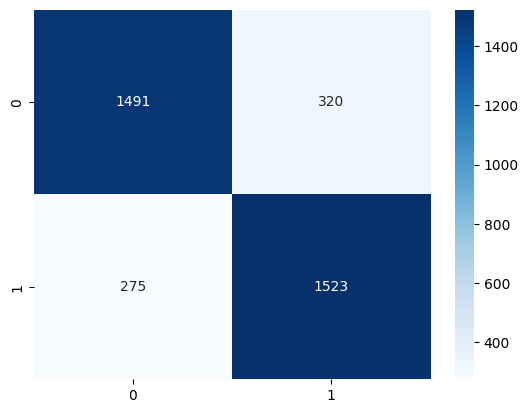

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

print("🚀 Iniciando a busca pelos melhores hiperparâmetros com GridSearchCV...")

# --- 1. Definir o "Grid" de parâmetros que queremos testar ---
# Um dicionário com os parâmetros e os valores que vamos experimentar
param_grid = {
    'n_estimators': [100, 200, 300],         # Número de "árvores" no modelo
    'max_depth': [3, 5, 7],                  # Profundidade máxima de cada árvore
    'learning_rate': [0.05, 0.1]             # Taxa de aprendizado (quão rápido o modelo aprende)
}

# --- 2. Preparar os dados (exatamente como antes) ---
features = [
    'orbital_period', 'transit_duration_hr', 'transit_depth_ppm', 
    'planet_radius_earth', 'stellar_temp_k', 'stellar_radius_solar',
    'stellar_mass_solar', 'impact_parameter', 'equilibrium_temp',
    'stellar_density', 'duration_over_period', 'depth_per_planet_radius'
]
X = df_featured[features].fillna(0)
y = df_featured['target']

# Vamos dividir os dados ANTES para ter um conjunto de teste real para o modelo final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- 3. Configurar e Rodar o GridSearchCV ---
# O GridSearchCV usará o X_train e y_train para fazer sua busca interna
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,          # Validação cruzada com 3 divisões
    n_jobs=-1,     # Usa todos os núcleos do seu processador
    verbose=2      # Mostra o progresso
)

print("💪 Treinando múltiplos modelos... Por favor, aguarde.")
grid_search.fit(X_train, y_train)

print("\n✅ Busca concluída!")

# --- 4. Exibir os melhores resultados encontrados ---
print("\n--- Melhores Parâmetros Encontrados ---")
print(grid_search.best_params_)

print(f"\nMelhor Acurácia (durante a busca): {grid_search.best_score_:.4f}")

# --- 5. Avaliar o MELHOR modelo no conjunto de teste ---
print("\n--- Avaliando o melhor modelo no conjunto de teste separado ---")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nAcurácia Final no Teste: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório de Classificação Final:")
print(classification_report(y_test, y_pred))
print("\nMatriz de Confusão Final:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

Treinando e Avaliando o Modelo XGBoost

🚀 Iniciando o treinamento do modelo XGBoost OTIMIZADO...
Dados divididos: 8419 para treino, 3609 para teste.
💪 Treinando o modelo final... Isso será rápido.
✅ Modelo final treinado com sucesso!

--- Resultados da Avaliação do Modelo Otimizado ---
Acurácia: 0.8365

Relatório de Classificação:
                    precision    recall  f1-score   support

Falso Positivo (0)       0.84      0.83      0.84      1811
       Planeta (1)       0.83      0.84      0.84      1798

          accuracy                           0.84      3609
         macro avg       0.84      0.84      0.84      3609
      weighted avg       0.84      0.84      0.84      3609


Matriz de Confusão:


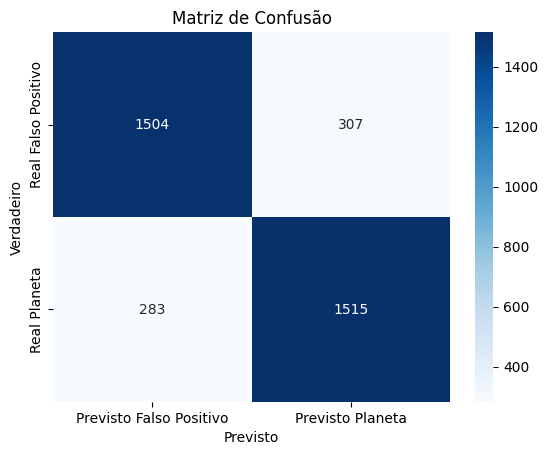

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Iniciando o treinamento do modelo XGBoost OTIMIZADO...")

# --- Passo 1: Separar Features (X) e Alvo (y) ---
features = [
    'orbital_period', 'transit_duration_hr', 'transit_depth_ppm', 
    'planet_radius_earth', 'stellar_temp_k', 'stellar_radius_solar',
    'stellar_mass_solar', 'impact_parameter', 'equilibrium_temp',
    'stellar_density', 'duration_over_period', 'depth_per_planet_radius',
    'signal_to_noise'  # <<< NOVA FEATURE ADICIONADA AQUI
]
X = df_featured[features]
y = df_featured['target']

# --- Passo 2: Lidar com valores ausentes ---
X = X.fillna(0)

# --- Passo 3: Dividir dados em Treino e Teste ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,
    random_state=42,
    stratify=y
)
print(f"Dados divididos: {X_train.shape[0]} para treino, {X_test.shape[0]} para teste.")

# --- Passo 4: Treinar o Modelo XGBoost OTIMIZADO ---
# Instanciamos o classificador com os MELHORES PARÂMETROS encontrados pelo GridSearchCV
model = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='logloss',
    random_state=42,
    # --- PARÂMETROS OTIMIZADOS ---
    learning_rate=0.05,
    max_depth=7,
    n_estimators=300
)

print("💪 Treinando o modelo final... Isso será rápido.")
model.fit(X_train, y_train)
print("✅ Modelo final treinado com sucesso!")

# --- Passo 5: Avaliar o Modelo Final ---
print("\n--- Resultados da Avaliação do Modelo Otimizado ---")
y_pred = model.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Falso Positivo (0)', 'Planeta (1)']))
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto Falso Positivo', 'Previsto Planeta'], 
            yticklabels=['Real Falso Positivo', 'Real Planeta'])
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

In [9]:
import pandas as pd

# Supondo que 'df_featured' é o seu DataFrame final, 
# contendo as colunas 'source', 'kepid', e 'tid'.

print("Gerando listas de alvos para a equipe ExoMiner...")

# --- 1. Gerar a lista de IDs do Kepler ---
kepler_df = df_featured[df_featured['source'] == 'Kepler']
kepler_ids = kepler_df['kepid'].dropna().unique().astype(int)

kepler_ids_df = pd.DataFrame(kepler_ids, columns=['kepid'])
kepler_ids_df.to_csv('kepler_ids_para_predicao.csv', index=False)

print(f"✅ Arquivo 'kepler_ids_para_predicao.csv' gerado com {len(kepler_ids_df)} alvos únicos do Kepler.")


# --- 2. Gerar a lista de IDs do TESS ---
tess_df = df_featured[df_featured['source'] == 'TESS']
# A coluna de ID do TESS pode ter vindo como 'tid' do nosso processamento
tess_ids = tess_df['tid'].dropna().unique().astype(int)

# O modelo ExoMiner do Márcio espera a coluna como 'tic_id', então já vamos renomear.
tess_ids_df = pd.DataFrame(tess_ids, columns=['tic_id'])
tess_ids_df.to_csv('tess_ids_para_predicao.csv', index=False)

print(f"✅ Arquivo 'tess_ids_para_predicao.csv' gerado com {len(tess_ids_df)} alvos únicos do TESS.")

Gerando listas de alvos para a equipe ExoMiner...
✅ Arquivo 'kepler_ids_para_predicao.csv' gerado com 8214 alvos únicos do Kepler.
✅ Arquivo 'tess_ids_para_predicao.csv' gerado com 2339 alvos únicos do TESS.


In [10]:
import pandas as pd
import numpy as np

# Supondo que 'df_featured' é o seu DataFrame final com as colunas 
# 'target', 'kepid', e 'tid' já corrigidas e presentes.

print("Gerando arquivo de predições simuladas (mock) do ExoMiner...")

# 1. Criar a coluna unificada 'target_id' se ainda não existir
if 'target_id' not in df_featured.columns:
    df_featured['target_id'] = df_featured['kepid'].fillna(df_featured['tid'])

# 2. Função para simular o score
def simular_score_exominer(target_real):
    if target_real == 1:
        # Se for um planeta, gera um score alto e com um pouco de variação
        return np.random.uniform(0.7, 0.99)
    else:
        # Se for um falso positivo, gera um score baixo com variação
        return np.random.uniform(0.01, 0.3)

# 3. Aplicar a função para cada linha do nosso dataset
exominer_mock_scores = df_featured['target'].apply(simular_score_exominer)

# 4. Montar o DataFrame de predições no formato que precisamos
exominer_mock_df = pd.DataFrame({
    'target_id': df_featured['target_id'].astype(int),
    'exominer_score': exominer_mock_scores
})

# 5. Salvar o arquivo CSV
output_path = 'exominer_predictions_mock.csv'
exominer_mock_df.to_csv(output_path, index=False)

print(f"✅ Arquivo de predições simuladas '{output_path}' gerado com sucesso!")
print("Amostra do arquivo gerado:")
print(exominer_mock_df.head())

Gerando arquivo de predições simuladas (mock) do ExoMiner...
✅ Arquivo de predições simuladas 'exominer_predictions_mock.csv' gerado com sucesso!
Amostra do arquivo gerado:
   target_id  exominer_score
0   10797460        0.835299
1   10797460        0.954249
2   10811496        0.722578
3   10848459        0.221037
4   10854555        0.866876


In [12]:
import joblib

# Supondo que 'best_model' é o seu modelo final do grid_search
joblib.dump(model, 'xgboost_model.pkl') 
print("Modelo XGBoost salvo com sucesso em 'xgboost_model.pkl'")

Modelo XGBoost salvo com sucesso em 'xgboost_model.pkl'


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

print("🚀 Iniciando a Tarefa 1.3: Treinamento do Meta-Modelo de Stacking...")

# --- Passo 1: Gerar as predições do nosso XGBoost Otimizado ---
print("   - Gerando predições do XGBoost...")

# Preparar os dados de entrada (X)
# Certifique-se de que a variável 'df_featured' e 'model' estejam carregadas e prontas
features_xgboost = [
    'orbital_period', 'transit_duration_hr', 'transit_depth_ppm', 
    'planet_radius_earth', 'stellar_temp_k', 'stellar_radius_solar',
    'stellar_mass_solar', 'impact_parameter', 'equilibrium_temp',
    'stellar_density', 'duration_over_period', 'depth_per_planet_radius',
    'signal_to_noise'
]
X_full = df_featured[features_xgboost].fillna(0)

# Gerar as probabilidades da classe 1 (Planeta)
# AQUI ESTÁ A CORREÇÃO: Usando a variável 'model'
xgboost_scores = model.predict_proba(X_full)[:, 1]

# Montar o DataFrame com os scores e IDs
xgboost_predictions_df = pd.DataFrame({
    'target_id': df_featured['target_id'].astype(int),
    'xgboost_score': xgboost_scores
})


# --- Passo 2: Carregar as predições (simuladas) do ExoMiner ---
print("   - Carregando predições simuladas do ExoMiner...")
try:
    exominer_predictions_df = pd.read_csv('exominer_predictions_mock.csv')
except FileNotFoundError:
    print("❌ ERRO: Arquivo 'exominer_predictions_mock.csv' não encontrado. Por favor, gere-o primeiro.")
    raise

# --- Passo 3: Criar o Dataset do Meta-Modelo (X_meta, y_meta) ---
print("   - Juntando os scores para criar o dataset do meta-modelo...")
meta_df = pd.merge(xgboost_predictions_df, exominer_predictions_df, on='target_id')

targets_df = df_featured[['target_id', 'target']].astype({'target_id': int})
meta_df = pd.merge(meta_df, targets_df, on='target_id')

X_meta = meta_df[['xgboost_score', 'exominer_score']]
y_meta = meta_df['target']


# --- Passo 4: Treinar o Meta-Modelo ---
print("   - Treinando o Meta-Modelo (Regressão Logística)...")
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    X_meta, y_meta, test_size=0.3, random_state=42, stratify=y_meta
)

meta_model = LogisticRegression(random_state=42)
meta_model.fit(X_train_meta, y_train_meta)


# --- Passo 5: Avaliar a performance do Stacking ---
print("\n--- Avaliação Final do Modelo Stacking ---")
y_pred_final = meta_model.predict(X_test_meta)
print(f"Acurácia Final do Stacking: {accuracy_score(y_test_meta, y_pred_final):.4f}")
print("\nRelatório de Classificação do Stacking:")
print(classification_report(y_test_meta, y_pred_final))


# --- Passo 6: Salvar o Meta-Modelo Treinado ---
joblib.dump(meta_model, 'meta_model.pkl')
print("\n✅ Meta-Modelo de Stacking salvo com sucesso em 'meta_model.pkl'")

🚀 Iniciando a Tarefa 1.3: Treinamento do Meta-Modelo de Stacking...
   - Gerando predições do XGBoost...
   - Carregando predições simuladas do ExoMiner...
   - Juntando os scores para criar o dataset do meta-modelo...
   - Treinando o Meta-Modelo (Regressão Logística)...

--- Avaliação Final do Modelo Stacking ---
Acurácia Final do Stacking: 0.9683

Relatório de Classificação do Stacking:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2309
           1       0.97      0.98      0.98      6693

    accuracy                           0.97      9002
   macro avg       0.96      0.95      0.96      9002
weighted avg       0.97      0.97      0.97      9002


✅ Meta-Modelo de Stacking salvo com sucesso em 'meta_model.pkl'


In [15]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd

print("🚀 Iniciando a Tarefa 1.4: Preparação dos componentes do 'Vizinho Mais Próximo'...")

# O 'meta_df' que criamos na etapa anterior já tem os scores.
# Precisamos juntá-lo com as features originais para a busca.
# Supondo que 'df_featured' tem todas as colunas de features e o 'target_id'.
reference_db = pd.merge(df_featured, meta_df[['target_id', 'exominer_score']], on='target_id')

# 1. Defina as features para a busca (o espaço de similaridade)
features_para_busca = [
    'orbital_period', 'transit_depth_ppm', 'signal_to_noise', 
    'planet_radius_earth', 'stellar_radius_solar'
]

# 2. Crie e salve o Scaler
scaler = StandardScaler()
# Usamos .fillna(0) para garantir que não há valores nulos antes de treinar o scaler
scaler.fit(reference_db[features_para_busca].fillna(0))
joblib.dump(scaler, 'scaler.pkl')
print("   - Scaler salvo com sucesso em 'scaler.pkl'")

# 3. Crie e salve o Buscador (NearestNeighbors)
scaled_reference_features = scaler.transform(reference_db[features_para_busca].fillna(0))
nn_finder = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn_finder.fit(scaled_reference_features)
joblib.dump(nn_finder, 'nn_finder.pkl')
print("   - Buscador de Vizinhos salvo com sucesso em 'nn_finder.pkl'")

# 4. Salve a base de referência completa
reference_db.to_csv('reference_db.csv', index=False)
print("   - Base de referência salva com sucesso em 'reference_db.csv'")

print("\n✅ Componentes do 'Vizinho Mais Próximo' prontos para produção.")

🚀 Iniciando a Tarefa 1.4: Preparação dos componentes do 'Vizinho Mais Próximo'...
   - Scaler salvo com sucesso em 'scaler.pkl'
   - Buscador de Vizinhos salvo com sucesso em 'nn_finder.pkl'
   - Base de referência salva com sucesso em 'reference_db.csv'

✅ Componentes do 'Vizinho Mais Próximo' prontos para produção.
